# ==========================================================
# AI-POWERED CUSTOMER RETENTION INTELLIGENCE PLATFORM
#
# PHASE 9
# AI CUSTOMER EXPLANATION
#
# NOTEBOOK:
# 02_AI_Customer_Explanation.ipynb
# ==========================================================

In [1]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import os
import pandas as pd

print("=" * 60)
print("LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 60)

LIBRARIES IMPORTED SUCCESSFULLY


In [2]:
# ==========================================================
# PROJECT ROOT
# ==========================================================

PROJECT_ROOT = os.path.abspath("..")

print(PROJECT_ROOT)

d:\AI-Powered-Customer-Retention-Intelligence-Platform


In [3]:
# ==========================================================
# LOAD AI READY DATASET
# ==========================================================

dataset_path = os.path.join(
    PROJECT_ROOT,
    "data",
    "final",
    "ai_ready_dataset.csv"
)

customer_data = pd.read_csv(dataset_path)

print("=" * 60)
print("AI DATASET LOADED")
print("=" * 60)

print(customer_data.head())

print(customer_data.shape)

AI DATASET LOADED
                 customer_unique_id  Frequency  Monetary  average_order_value  \
0  0000366f3b9a7992bf8c76cfdf3221e2          1    141.90               141.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f          1     27.19                27.19   
2  0000f46a3911fa3c0805444483337064          1     86.22                86.22   
3  0000f6ccb0745a6a4b88665a16c9f078          1     43.62                43.62   
4  0004aac84e0df4da2b147fca70cf8255          1    196.89               196.89   

   average_review_score preferred_payment_method  Risk_Probability Risk_Level  \
0                   5.0              credit_card          0.683347     Medium   
1                   4.0              credit_card          0.617935     Medium   
2                   3.0              credit_card          0.777345       High   
3                   4.0              credit_card          0.748424       High   
4                   5.0              credit_card          0.677529     Medium   

   Prior

In [4]:
# ==========================================================
# CUSTOMER AI EXPLANATION
# ==========================================================

def generate_customer_explanation(row):

    return (
        f"This customer is classified as {row['Risk_Level']} churn risk. "
        f"The customer belongs to the {row['Customer_Value']} segment with "
        f"an average review score of {row['average_review_score']:.1f}. "
        f"The recommended business action is '{row['Recommendation']}' "
        f"through the '{row['Campaign_Type']}' campaign. "
        f"Expected outcome: {row['Expected_Outcome']}."
    )

customer_data["AI_Customer_Explanation"] = customer_data.apply(
    generate_customer_explanation,
    axis=1
)

print("=" * 60)
print("CUSTOMER EXPLANATIONS GENERATED")
print("=" * 60)

print(
    customer_data[
        [
            "customer_unique_id",
            "AI_Customer_Explanation"
        ]
    ].head()
)

CUSTOMER EXPLANATIONS GENERATED
                 customer_unique_id  \
0  0000366f3b9a7992bf8c76cfdf3221e2   
1  0000b849f77a49e4a4ce2b2a4ca5be3f   
2  0000f46a3911fa3c0805444483337064   
3  0000f6ccb0745a6a4b88665a16c9f078   
4  0004aac84e0df4da2b147fca70cf8255   

                             AI_Customer_Explanation  
0  This customer is classified as Medium churn ri...  
1  This customer is classified as Medium churn ri...  
2  This customer is classified as High churn risk...  
3  This customer is classified as High churn risk...  
4  This customer is classified as Medium churn ri...  


In [5]:
# ==========================================================
# EXPLANATION LENGTH
# ==========================================================

customer_data["Explanation_Length"] = (
    customer_data["AI_Customer_Explanation"]
    .str.len()
)

print("=" * 60)
print("EXPLANATION LENGTH SUMMARY")
print("=" * 60)

print(
    customer_data["Explanation_Length"]
    .describe()
)

EXPLANATION LENGTH SUMMARY
count    96096.000000
mean       264.302073
std          4.543011
min        253.000000
25%        263.000000
50%        264.000000
75%        266.000000
max        278.000000
Name: Explanation_Length, dtype: float64


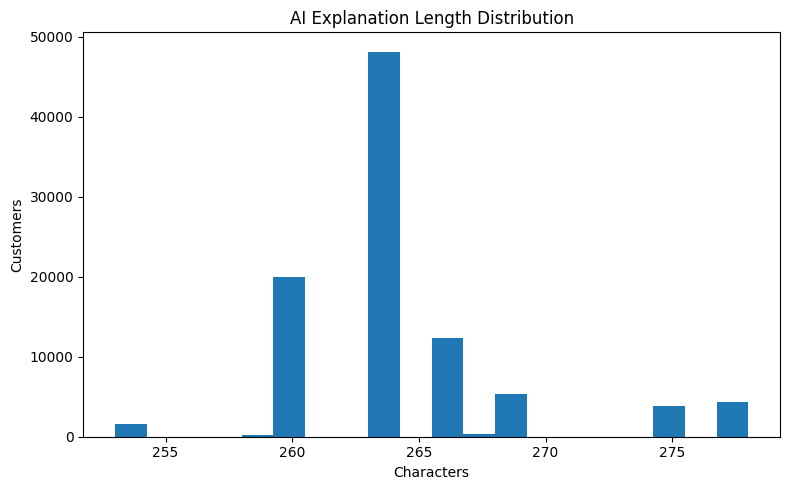

In [6]:
# ==========================================================
# EXPLANATION LENGTH DISTRIBUTION
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    customer_data["Explanation_Length"],
    bins=20
)

plt.title("AI Explanation Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Customers")

plt.tight_layout()

plt.show()

In [7]:
# ==========================================================
# SAVE CUSTOMER EXPLANATIONS
# ==========================================================

final_folder = os.path.join(
    PROJECT_ROOT,
    "data",
    "final"
)

os.makedirs(
    final_folder,
    exist_ok=True
)

output_path = os.path.join(
    final_folder,
    "ai_customer_explanations.csv"
)

customer_data.to_csv(
    output_path,
    index=False
)

print("=" * 60)
print("AI CUSTOMER EXPLANATIONS SAVED")
print("=" * 60)

print(output_path)

AI CUSTOMER EXPLANATIONS SAVED
d:\AI-Powered-Customer-Retention-Intelligence-Platform\data\final\ai_customer_explanations.csv
